<a href="https://colab.research.google.com/github/BukolaEasy/BukolaEasy/blob/main/curriculum/phase-2a-python/weeks-01-08-teaching/week-08-visualisation-and-streamlit/01-wednesday/exercises/week-08-wed-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 — Visualisation with matplotlib & seaborn: Exercises
## Phase 2a Python | PORA Academy Cohort 7 | Wednesday

Welcome to your Week 8 Wednesday practice. Today you turn the Olist data into **charts** — the way analysts actually communicate findings to a business.

**How to work through this notebook:**
- **Read each question carefully.** Each one tells you exactly which chart to build and which columns to use.
- **Run the Data Setup cell first** (the one right below). Every question depends on the DataFrames it loads.
- Write your answer in the `# Your code here` block. Do not edit the given variables.
- **Check your work against the expected output hint** printed in each question. If your chart's peak, total, or counts do not match the hint, something is off — revisit your grouping or filtering before moving on.
- Every chart needs a **title, axis labels, and a sensible `figsize`**. A chart with no labels does not communicate anything.

Charts you will practise today: **line**, **vertical bar**, **horizontal bar**, **seaborn countplot**, and **pie**.

Good luck — and make your charts readable!

## Data Setup — run this first

This cell mounts Google Drive and loads all eight Olist tables. After it runs successfully you will have these DataFrames ready to use in every question:
`orders`, `customers`, `order_items`, `products`, `reviews`, `payments`, `sellers`, and `product_translations`.

You do **not** need to re-load the data in any question below.

In [3]:
import pandas as pd
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
olist_path = '/content/drive/MyDrive/olist_order_dataset'

# Load all datasets
orders = pd.read_csv(os.path.join(olist_path, 'olist_orders_dataset.csv'))
customers = pd.read_csv(os.path.join(olist_path, 'olist_customers_dataset.csv'))
order_items = pd.read_csv(os.path.join(olist_path, 'olist_order_items_dataset.csv'))
products = pd.read_csv(os.path.join(olist_path, 'olist_products_dataset.csv'))
reviews = pd.read_csv(os.path.join(olist_path, 'olist_order_reviews_dataset.csv'))
payments = pd.read_csv(os.path.join(olist_path, 'olist_order_payments_dataset.csv'))
sellers = pd.read_csv(os.path.join(olist_path, 'olist_sellers_dataset.csv'))
product_translations = pd.read_csv(os.path.join(olist_path, 'product_category_name_translation.csv'))

# Verify datasets loaded
print(f"✓ Loaded {len(orders):,} orders")
print(f"✓ Loaded {len(customers):,} customers")
print(f"✓ Loaded {len(order_items):,} order items")
print(f"✓ Loaded {len(products):,} products")
print(f"✓ Loaded {len(reviews):,} reviews")
print(f"✓ Loaded {len(payments):,} payments")
print(f"✓ Loaded {len(sellers):,} sellers")
print(f"✓ Loaded {len(product_translations):,} product translations")

# Quick data checks
print(f"\nOrders shape: {orders.shape}")
print(f"Orders columns: {orders.columns.tolist()}")
print(f"Date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded 99,441 orders
✓ Loaded 99,441 customers
✓ Loaded 112,650 order items
✓ Loaded 32,951 products
✓ Loaded 99,224 reviews
✓ Loaded 103,886 payments
✓ Loaded 3,095 sellers
✓ Loaded 71 product translations

Orders shape: (99441, 8)
Orders columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


We also need the two plotting libraries for every question below. Run this cell once.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the timestamp column is a real datetime so we can pull the month/year out of it
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
print("Ready to plot.")

Ready to plot.


## Question 1 — Line chart: monthly order volume in 2017

Build a **line chart** showing the number of orders for each month of **2017**.

Steps to think through:
1. Filter `orders` to rows where the purchase year is 2017.
2. Create a month key, e.g. `orders['order_purchase_timestamp'].dt.to_period('M')`.
3. Group by that month key and **count** the orders.
4. Plot with `plt.plot(...)`, using `marker='o'` so each month is visible.

Format it properly: `figsize=(12, 5)`, a title, x-label `Month`, y-label `Number of Orders`, and `plt.xticks(rotation=45)`.

**Expected output hint:** the line should climb through the year and **peak in November 2017 at 7,544 orders** (Black Friday). If your November value is not 7,544, check your filtering and grouping.

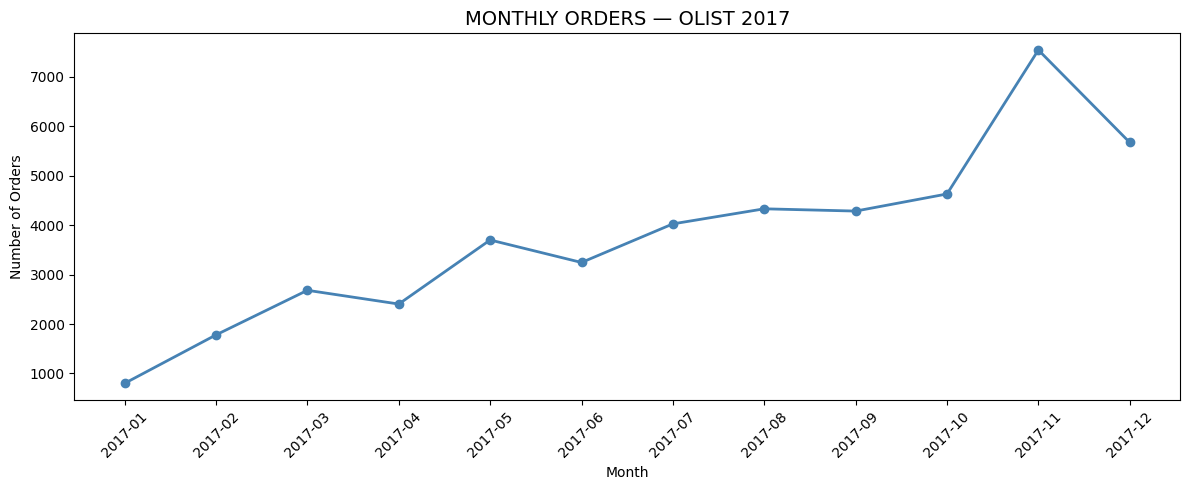

November 2017 orders: 7,544


In [6]:
# Your code here
#convert timestamp to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

#1. Filter for 2017 only
orders_2017 = orders[orders['order_purchase_timestamp'].dt.year == 2017].copy()

#2. Create a month key
orders_2017['month'] = orders_2017['order_purchase_timestamp'].dt.to_period('M')

#3. Group by month and count the orders
monthly = orders_2017.groupby('month')['order_id'].count()

#4. Plot
plt.figure(figsize=(12, 5))
plt.plot(monthly.index.astype(str), monthly.values,
         marker='o', linewidth=2, color='steelblue')
plt.title('MONTHLY ORDERS — OLIST 2017', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"November 2017 orders: {monthly.loc['2017-11']:,}")

## Question 2 — Vertical bar chart: order status distribution

Build a **vertical bar chart** of the order statuses in the full `orders` table.

Steps:
1. Use `orders['order_status'].value_counts()` to get the count of each status.
2. Take the top 5 statuses.
3. Plot with `plt.bar(...)`, passing a list of colours if you like.

Format it: `figsize=(8, 4)`, a title, and a y-label `Count`.

**Expected output hint:** `delivered` should dominate the chart by a wide margin — the vast majority of the ~99,441 orders were delivered. The other statuses (shipped, canceled, etc.) should be tiny bars by comparison.

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
Name: count, dtype: int64


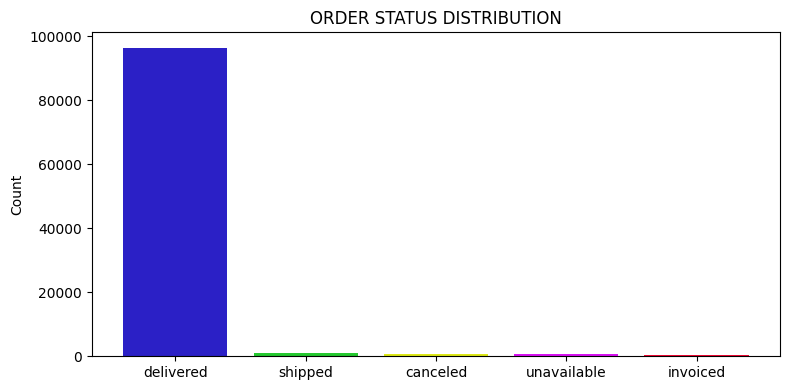

In [7]:
# Your code here
#1,2. Top 5 Order count
status = orders['order_status'].value_counts().head(5)
print(status)

#3.plot
plt.figure(figsize=(8, 4))
plt.bar(status.index, status.values,
        color=["#2b20c6", "#25c830", "#dde818", "#d912f3", "#f40934"])
plt.title('ORDER STATUS DISTRIBUTION')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Question 3 — seaborn countplot: review score distribution

Now switch to **seaborn**. Build a **countplot** of `review_score` from the `reviews` DataFrame.

Steps:
1. Call `sns.countplot(data=reviews, x='review_score', palette='RdYlGn')`.
2. Add a title, x-label `Review Score`, and y-label `Count`.
3. Use `figsize=(8, 4)` (set it with `plt.figure(figsize=(8, 4))` **before** the countplot call).

**Expected output hint:** the bars, in score order 1 to 5, should be **[11424, 3151, 8179, 19142, 57328]**. The 5-star bar (57,328) should tower over the rest, and the 2-star bar (3,151) should be the shortest. This is a left-skewed, mostly-happy customer base.

/tmp/ipykernel_2161/3862483988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='RdYlGn')


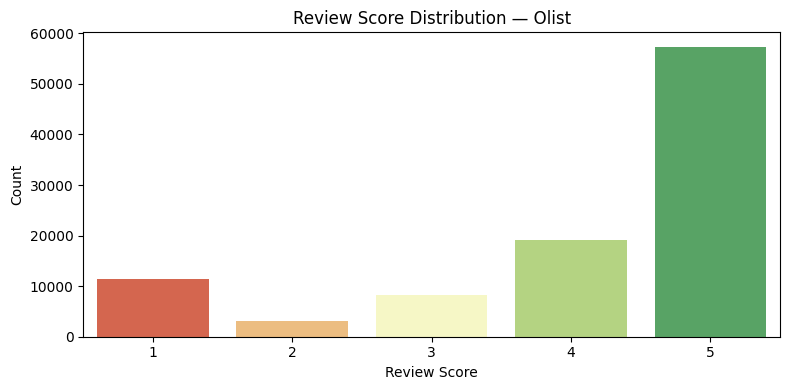

5-star reviews: 57,328
4-star reviews: 19,142
3-star reviews: 8,179
2-star reviews: 3,151
1-star reviews: 11,424


In [9]:
# Your code here

plt.figure(figsize=(8, 4))
sns.countplot(data=reviews, x='review_score', palette='RdYlGn')
plt.title('Review Score Distribution — Olist')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

score_counts = reviews['review_score'].value_counts().sort_index()
print(f"5-star reviews: {score_counts.loc[5]:,}")
print(f"4-star reviews: {score_counts.loc[4]:,}")
print(f"3-star reviews: {score_counts.loc[3]:,}")
print(f"2-star reviews: {score_counts.loc[2]:,}")
print(f"1-star reviews: {score_counts.loc[1]:,}")


## Question 4 — Pie chart: payment method breakdown

Build a **pie chart** showing the share of each payment type in the `payments` DataFrame.

Steps:
1. Use `payments['payment_type'].value_counts()`.
2. Pass the values and labels to `plt.pie(...)`, and use `autopct='%1.1f%%'` so each slice shows its percentage.
3. Give it a title and a square `figsize=(7, 7)` so the pie is round.

**Expected output hint:** the slices should read approximately **credit_card 73.9%**, **boleto 19.0%**, **voucher 5.6%**, and **debit_card 1.5%**. Credit card should be by far the largest slice.

Credit card share: 73.9%
Boleto share: 19.0%


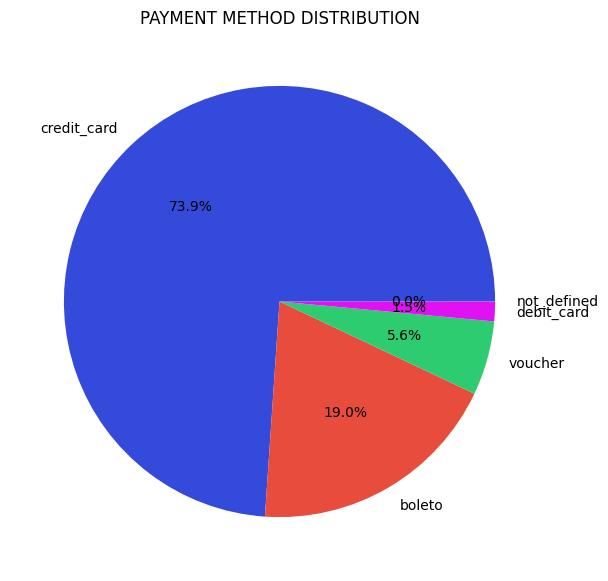

In [10]:
# Your code here

pay_counts = payments['payment_type'].value_counts()
pay_pct = payments['payment_type'].value_counts(normalize=True) * 100
print(f"Credit card share: {pay_pct.loc['credit_card']:.1f}%")
print(f"Boleto share: {pay_pct.loc['boleto']:.1f}%")

plt.figure(figsize=(7, 7))
plt.pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
        colors=["#344adb", '#e74c3c', '#2ecc71', "#e012f3", "#fcf805"])
plt.title('PAYMENT METHOD DISTRIBUTION')
plt.show()

---
## Part 5 — Group Exercise (40 min)

Work in your group. You will build a small **three-chart "dashboard"** from the Olist data — the same kind of visual summary you will hand to a business stakeholder in the Capstone. Each chart uses **verified numbers**, so you can check your work as you go.

Build all three charts below. Give every chart a title and labelled axes.

### Group Chart 1 — Monthly order volume for 2017 (line chart)

Re-create the monthly line chart for 2017 (same idea as Question 1). Filter to 2017, group orders by month, count them, and plot a line with markers.

**Expected output hint:** the peak is **November 2017 = 7,544 orders**.

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
Name: count, dtype: int64

November 2017 orders: 7,544


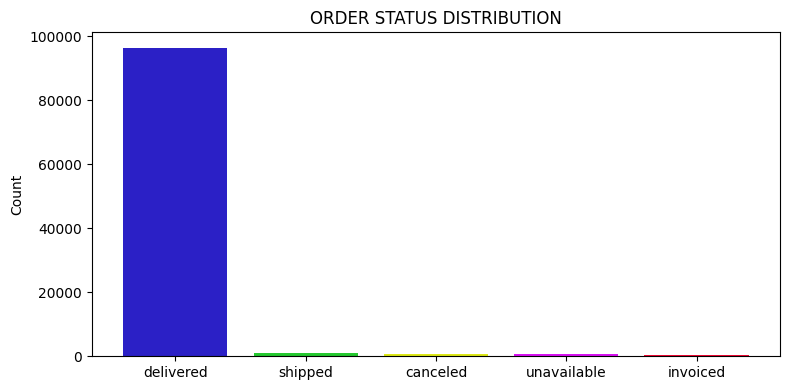

In [11]:
# Your code here
status = orders['order_status'].value_counts().head(5)
print(status)
print()
print(f"November 2017 orders: {monthly.loc['2017-11']:,}")
plt.figure(figsize=(8, 4))
plt.bar(status.index, status.values,
        color=["#2b20c6", "#25c830", "#dde818", "#d912f3", "#f40934"])
plt.title('ORDER STATUS DISTRIBUTION')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Group Chart 2 — Top 10 states by total orders (horizontal bar chart)

Which Brazilian states place the most orders?

Steps:
1. Merge `orders` with `customers` on `customer_id` so each order gets a `customer_state`.
2. Use `value_counts()` on `customer_state` and take the top 10.
3. Plot with `plt.barh(...)` (a **horizontal** bar chart reads best for ranked categories).
4. Title it and label the x-axis `Number of Orders`.

**Expected output hint:** **SP (São Paulo)** should be far ahead of every other state at **41,746 orders**. The next states (RJ, MG) are well below it.

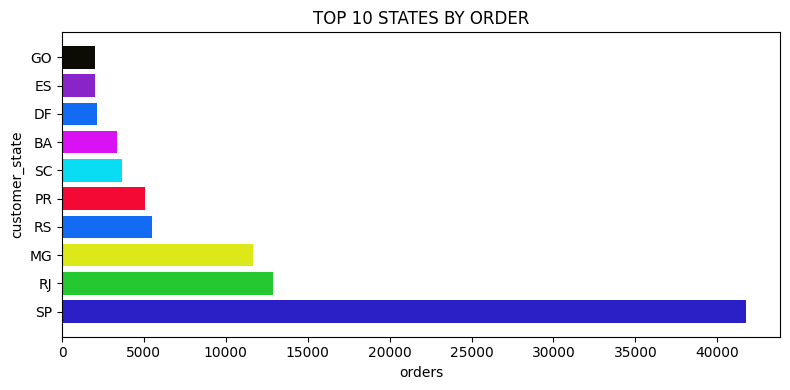

In [14]:
customer_state = orders.merge(customers, on='customer_id')
top_states = customer_state['customer_state'].value_counts().head(10)

plt.figure(figsize=(8, 4))
plt.barh(top_states.index, top_states.values,
        color=["#2b20c6", "#25c830", "#dde818", "#126cf3", "#f40934", "#09ddf4", "#d912f3", "#126cf3", "#8925c8","#0c0c05"])
plt.title('TOP 10 STATES BY ORDER')
plt.xlabel('orders')
plt.ylabel('customer_state')
plt.tight_layout()
plt.show()

### Group Chart 3 — Review score distribution (bar chart)

Build a bar chart of how many reviews received each score from 1 to 5. You can use `reviews['review_score'].value_counts().sort_index()` and `plt.bar(...)`, or a seaborn countplot as in Question 3.

Make sure the bars are in score order (1, 2, 3, 4, 5) on the x-axis.

**Expected output hint:** the counts, in order 1 to 5, are **[11424, 3151, 8179, 19142, 57328]**.

/tmp/ipykernel_2161/533459284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='review_score', palette='RdYlGn')


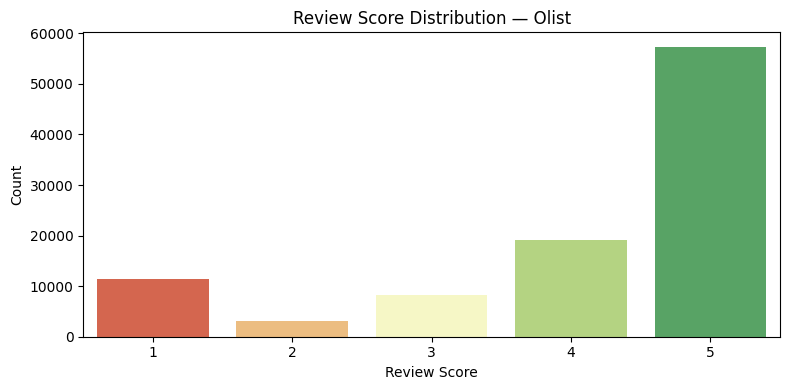

11424
3151
8179
19142
57328


In [15]:
# Your code here

score_counts = reviews['review_score'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
sns.countplot(data=reviews, x='review_score', palette='RdYlGn')
plt.title('Review Score Distribution — Olist')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



print(score_counts.loc[1])
print(score_counts.loc[2])
print(score_counts.loc[3])
print(score_counts.loc[4])
print(score_counts.loc[5])

### Group debrief

When all three charts are done, discuss as a group:
- What single business story do these three charts tell together? (Where do orders come from, when do they spike, and how happy are customers?)
- Which chart type was the right choice for each question, and why? (When is a line better than a bar? When is a horizontal bar better than a vertical one?)
- If you had to hand **one** of these charts to Ready Delight's manager, which would it be, and what title would you give it?

Be ready to share your three charts and your answers in the debrief.